# Boxplot 
### In this plot there is a exponent variable called lambda that varies over range of -5 to 5, and in the preocess of searching, we examine all values of lambda. Finally, we choose the optimal value (resulting in the best approximation to a normal distribution) for your variable.

#### It doesnt take zero and negative value.

In [23]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score

import scipy.stats as stats

In [24]:
df= pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/concrete.csv')

In [25]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [26]:
df.shape

(1030, 9)

In [27]:
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [28]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [29]:
x= df.drop(columns=['strength'])
y= df.iloc[:,-1]

In [30]:
y

0       29.89
1       23.51
2       29.22
3       45.85
4       18.29
        ...  
1025    13.29
1026    41.30
1027    44.28
1028    55.06
1029    52.61
Name: strength, Length: 1030, dtype: float64

In [31]:
x

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28
...,...,...,...,...,...,...,...,...
1025,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28
1026,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3
1027,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1028,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270


In [32]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [33]:
# apply without transformation

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.608111852511878

In [34]:
lr = LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring='r2'))

np.float64(0.6012883381757208)

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


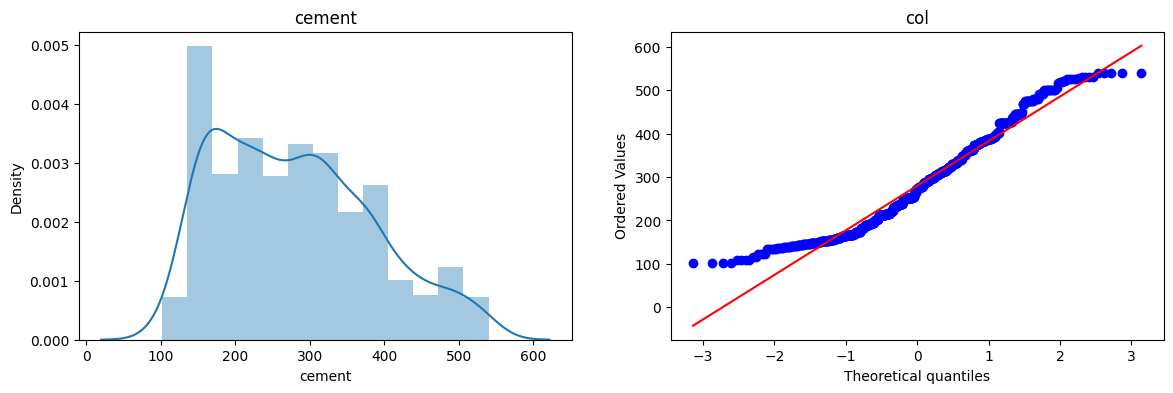

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


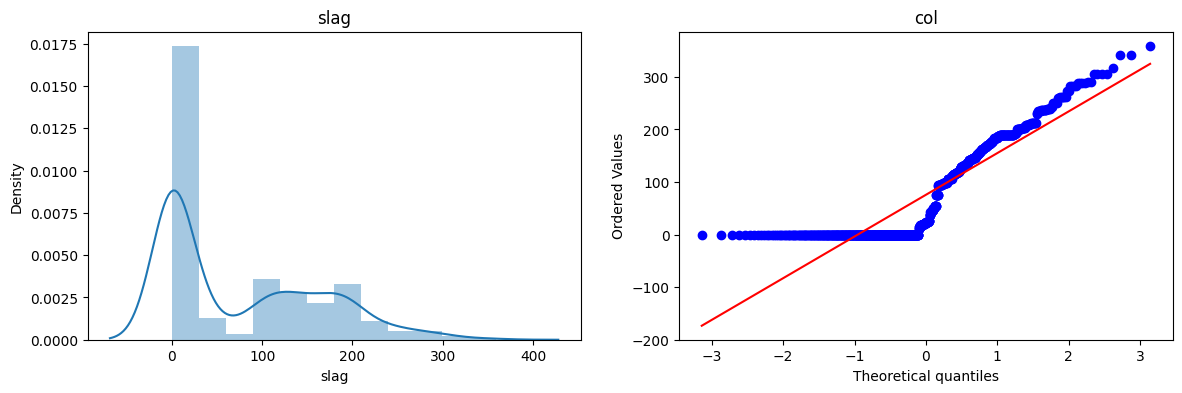

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


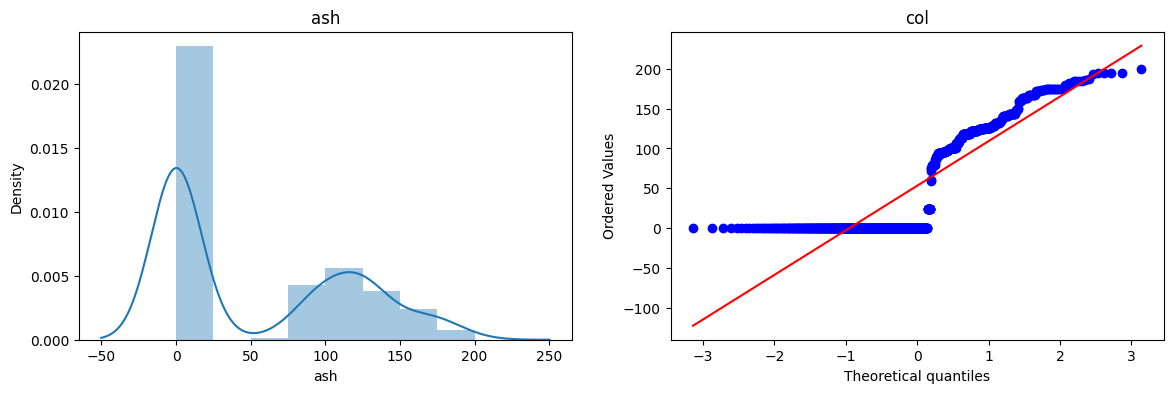

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


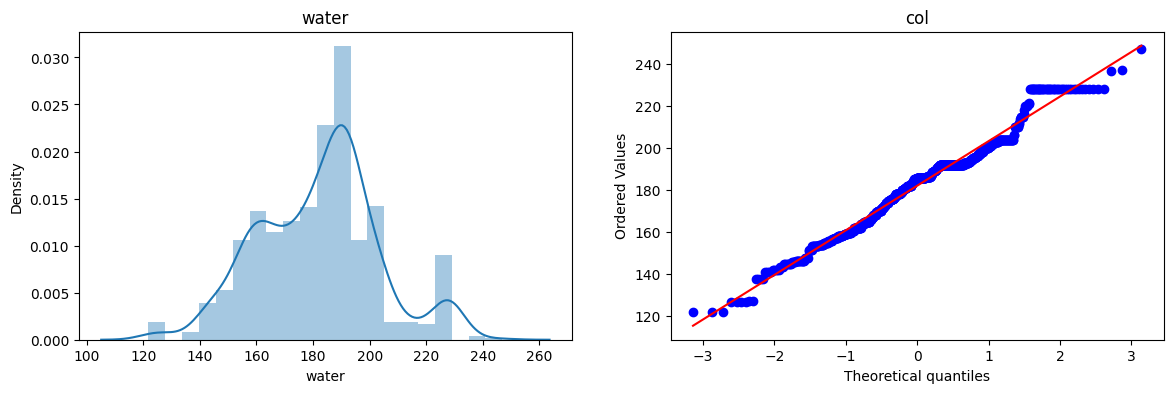

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


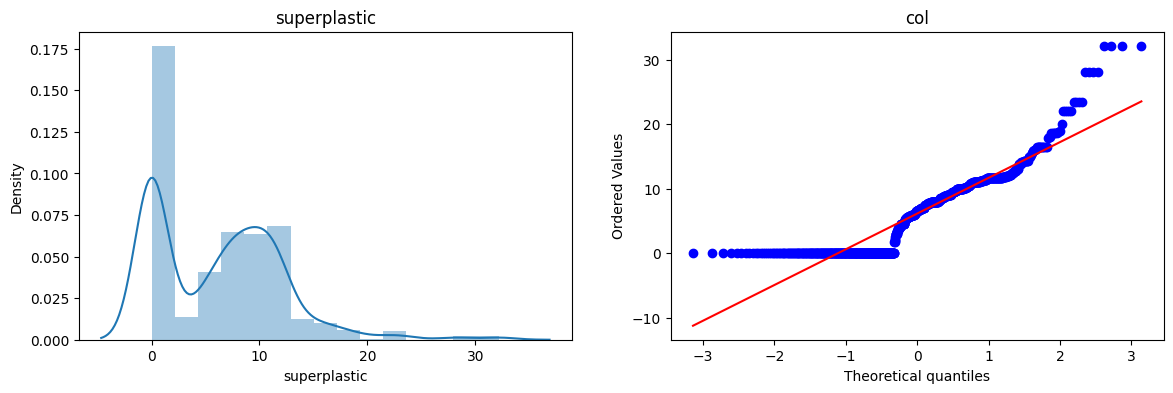

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


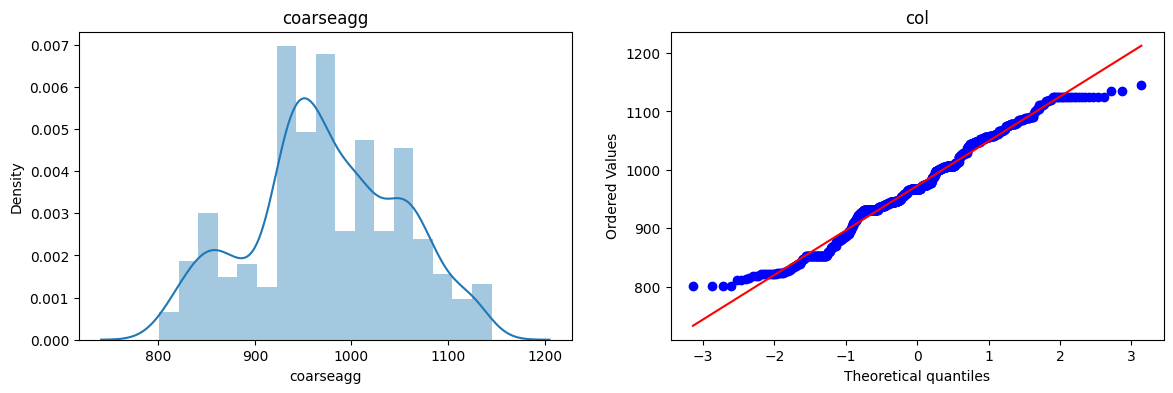

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


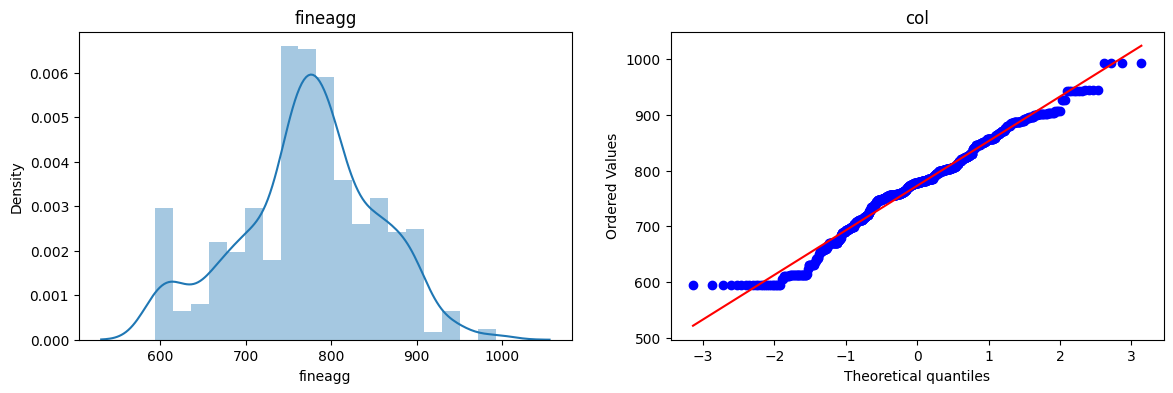

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_20734/3747593852.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


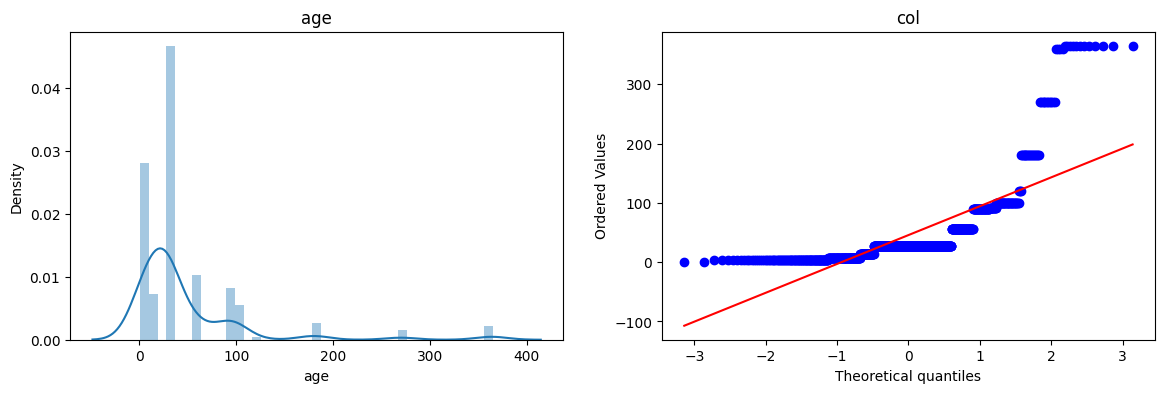

In [35]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist='norm', plot=plt)
    plt.title("col")
    plt.show()

In [36]:
# Applying BoxCox 

In [37]:
pt = PowerTransformer(method='box-cox')

x_train_transformed= pt.fit_transform(x_train+0.000001)
x_test_transformed= pt.fit_transform(x_test+0.000001)

pd.DataFrame({'cols': x_train.columns, 'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,cement,0.135676
1,slag,0.028685
2,ash,-0.012726
3,water,0.650155
4,superplastic,0.118418
5,coarseagg,0.788352
6,fineagg,2.235852
7,age,0.041510


In [38]:
lr = LinearRegression()
lr.fit(x_train_transformed,y_train)

y_pred1 =lr.predict(x_test_transformed)

r2_score(y_test,y_pred1)

0.782623507379329

In [39]:
pt =PowerTransformer(method='box-cox')
x_transformed =pt.fit_transform(x+0.000001)

lr= LinearRegression()

np.mean(cross_val_score(lr, x_transformed, y, scoring='r2'))

np.float64(0.7948176002909327)

In [42]:
x_train_transformed = pd.DataFrame( x_train_transformed,columns=x_train.columns)

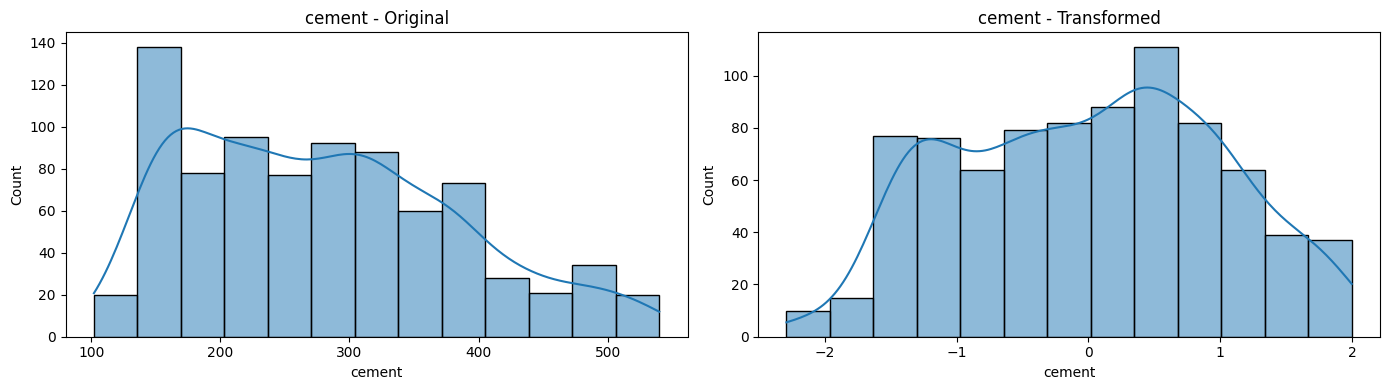

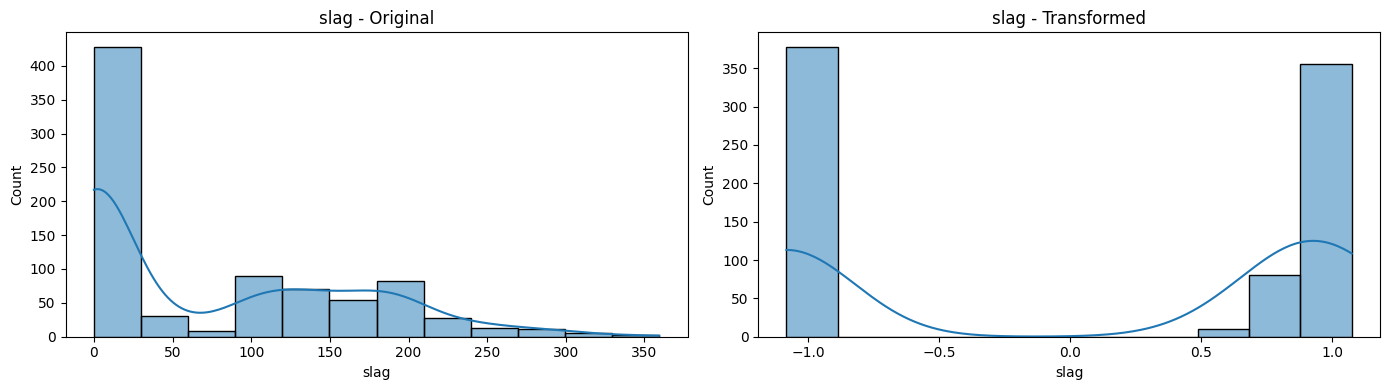

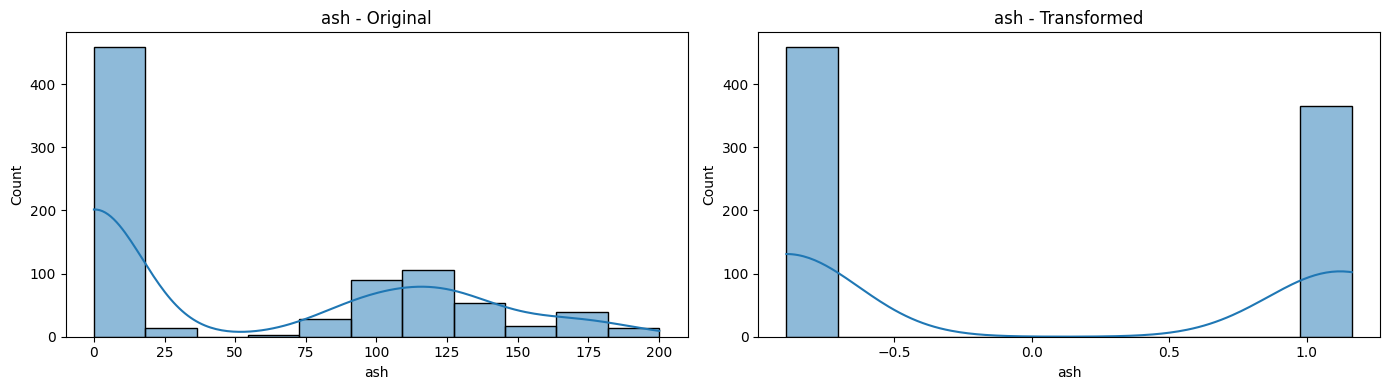

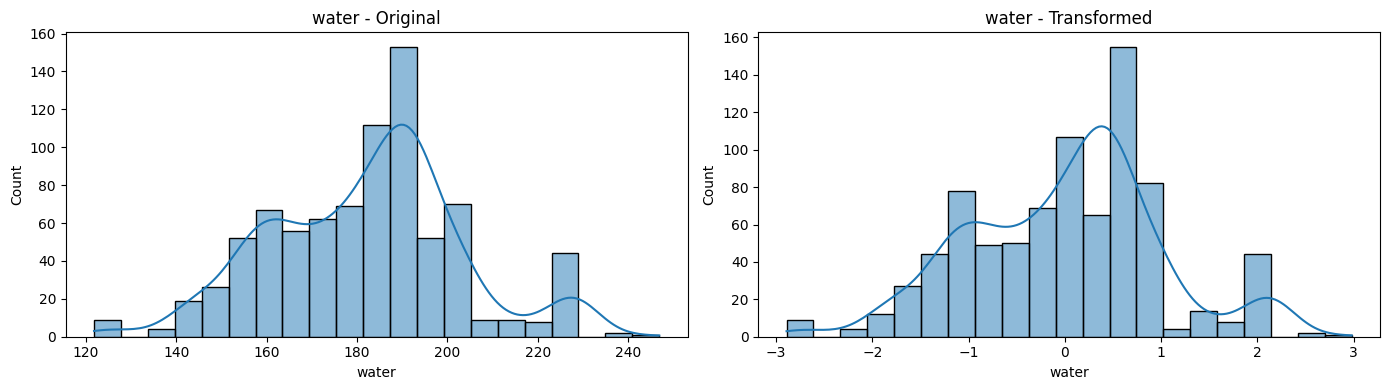

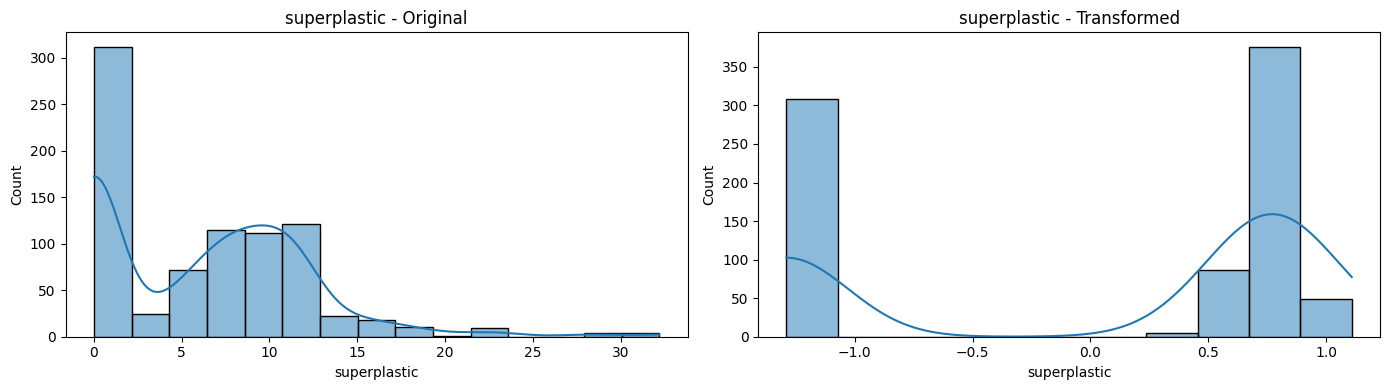

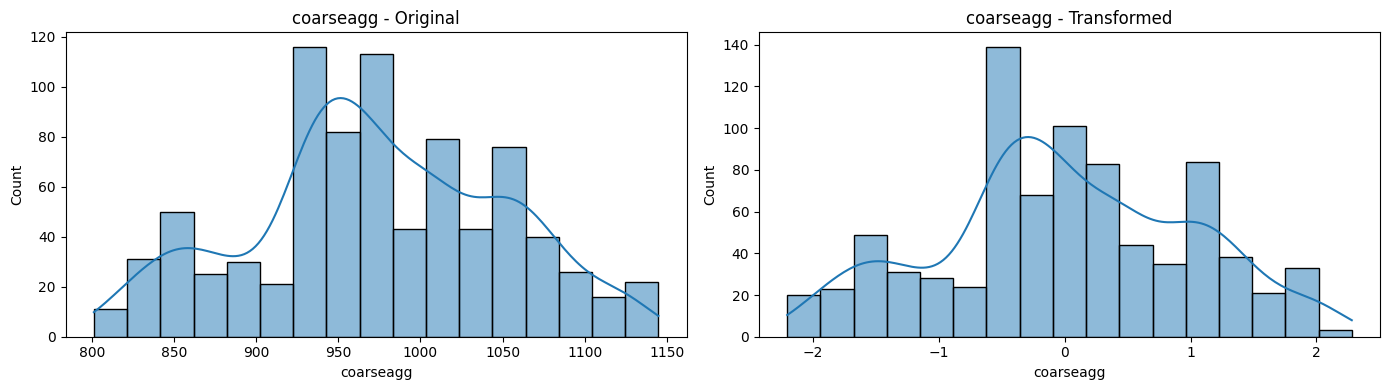

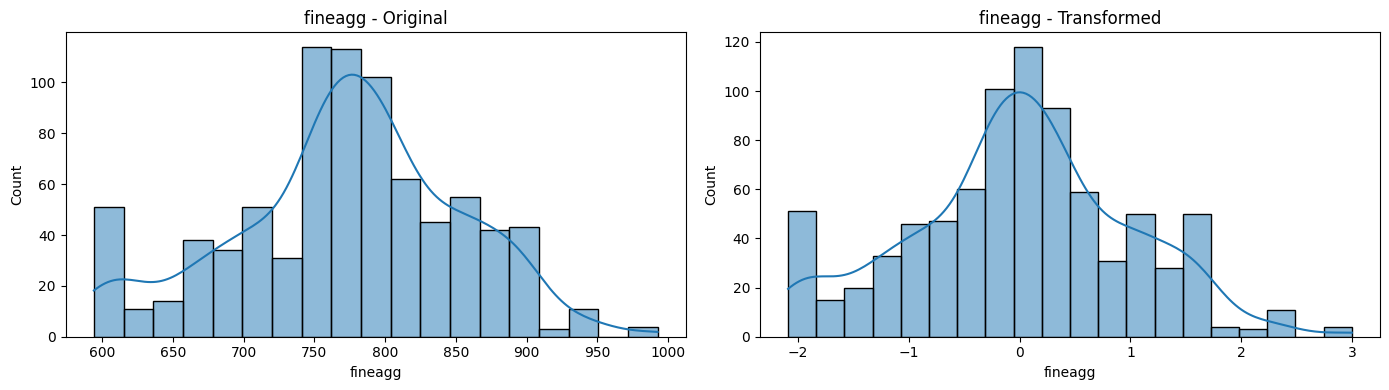

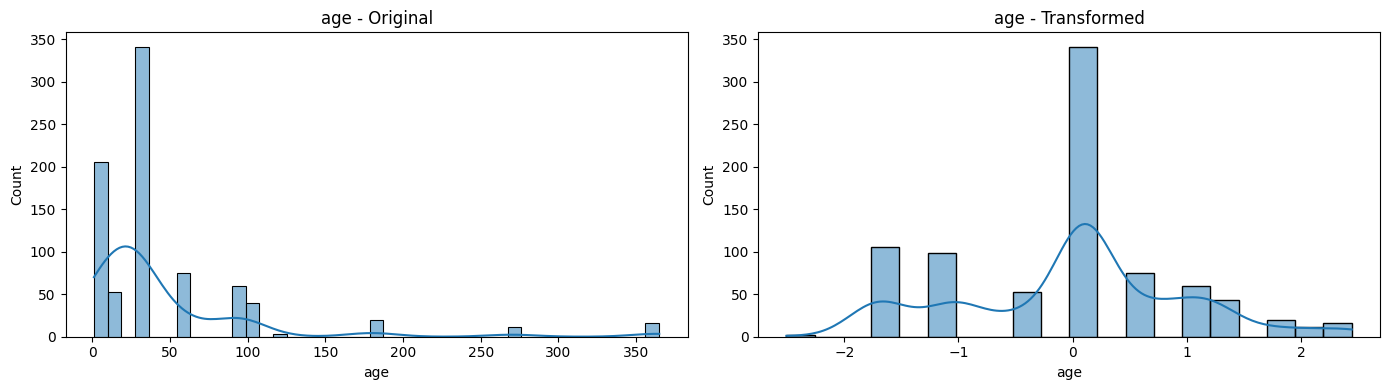

In [44]:
for col in x_train_transformed.columns:

    plt.figure(figsize=(14,4))

    # Original data
    plt.subplot(121)
    sns.histplot(x_train[col], kde=True)
    plt.title(f"{col} - Original")

    # Transformed data
    plt.subplot(122)
    sns.histplot(x_train_transformed[col], kde=True)
    plt.title(f"{col} - Transformed")

    plt.tight_layout()
    plt.show()

# Yeo-Johnson Trasform

In [49]:
pt1= PowerTransformer()

x_train_transformed1= pt1.fit_transform(x_train)
x_test_transformed2= pt1.fit_transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed1,y_train)

y_pred3= lr.predict(x_test_transformed2)
print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas': pt1.lambdas_})

0.7821442824620015


,cols,Yeo_Johnson_lambdas
0,cement,0.132769
1,slag,0.010700
2,ash,-0.058030
3,water,0.647969
4,superplastic,0.287425
5,coarseagg,0.788249
6,fineagg,2.237515
7,age,-0.003395


In [50]:
pt =PowerTransformer()
x_transformed3 =pt.fit_transform(x+0.000001)

lr= LinearRegression()

np.mean(cross_val_score(lr, x_transformed3, y, scoring='r2'))

np.float64(0.7989126842579558)